In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/out/videos.parquet")

# Ensure datetime
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")

# Drop missing timestamps
df = df.dropna(subset=["published_at"])

# Create monthly period
df["year_month"] = df["published_at"].dt.to_period("M")

# Convert to timestamp for plotting
df["year_month"] = df["year_month"].dt.to_timestamp()

/var/folders/6n/qbkx86t95c99jm_0m0p5yn7m0000gn/T/ipykernel_28076/1052716738.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["published_at"].dt.to_period("M")


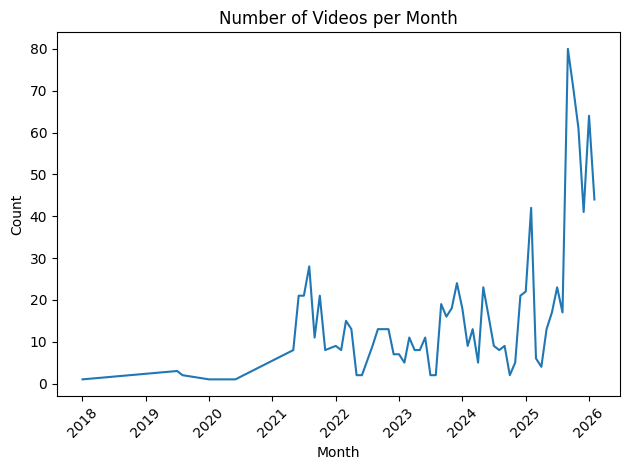

In [2]:
monthly_counts = (
    df.groupby("year_month")
      .size()
      .reset_index(name="n_videos")
)

plt.figure()
plt.plot(monthly_counts["year_month"], monthly_counts["n_videos"])
plt.title("Number of Videos per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
monthly_sentiment = (
    df.groupby("year_month")["sentiment"]
      .mean()
      .reset_index()
)

plt.figure()
plt.plot(monthly_sentiment["year_month"], monthly_sentiment["sentiment"])
plt.title("Average Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Mean Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

TypeError: dtype 'str' does not support operation 'mean'